# Imports, seeds, knobs

In [ ]:
import os, random, numpy as np, torch, inspect, re, sys
from typing import List, Tuple, Optional, Dict

from datasets import load_dataset, Dataset

import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
import matplotlib.pyplot as plt

# for reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True

# Project & run knobs (increased a bit)
PROJECT_DIR = "./marian_bilingual_en_es_pt_v2"
os.makedirs(PROJECT_DIR, exist_ok=True)

MAX_SAMPLES = 10000  # was 1200 
EVAL_SAMPLES = 500
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128
BATCH = 8
GRAD_ACCUM = 4        # effective batch size = 32
MAX_STEPS = 1000      # was 1000 – longer fine‑tuning

device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)()
use_fp16 = torch.cuda.is_available() and not use_bf16

print(f"Device={device} | bf16={use_bf16} | fp16={use_fp16}")
print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version in PyTorch:", torch.version.cuda)


j:\FINAL PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device=cuda | bf16=True | fp16=False
Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
PyTorch version: 2.10.0.dev20251124+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA version in PyTorch: 12.8


 # Load Marian models 

In [ ]:
#  EN to ES 
tok_es = AutoTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es",
    token=None,
    local_files_only=False,
    use_fast=True
)
mod_es = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es",
    token=None,
    local_files_only=False
).to(device)

# EN toPT 
tok_pt = AutoTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",
    token=None,
    local_files_only=False,
    use_fast=True
)
mod_pt = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",
    token=None,
    local_files_only=False
).to(device)

assert getattr(mod_es.config, "model_type", "") == "marian"
print(" Loaded EN→ES (Marian)")

assert getattr(mod_pt.config, "model_type", "") == "marian"
print(" Loaded EN→PT (Marian)")


✅ Loaded EN→ES (Marian)
✅ Loaded EN→PT (Marian)


# Glossary and safer RBMT protect and restore


In [ ]:
GLOSSARY = {
    "polymerase chain reaction": {"es": "reacción en cadena de la polimerasa", "pt": "reação em cadeia da polimerase"},
    "confidence interval": {"es": "intervalo de confianza", "pt": "intervalo de confiança"},
}

def apply_glossary(text: str, lang: str) -> str:
    out = text
    for en_term, mapping in GLOSSARY.items():
        if lang in mapping:
            out = out.replace(en_term, mapping[lang])
    return out

#  PATTERNS TO PROTECT 
EQ_PATTERN   = re.compile(r"\b(?:log|ln|exp|sin|cos|tan)\s*\([^)]*\)")
LATEX_EQ     = re.compile(r"\$[^$]+\$")
CIT_PATTERN  = re.compile(r"[A-Z][a-z]+ et al\.\s*\(\d{4}\)")
PERC_PATTERN = re.compile(r"\d+(?:[.,]\d+)?\s*%")
NUM_PATTERN  = re.compile(r"\d+(?:[.,]\d+)?")

PROTECT_PATTERNS = [LATEX_EQ, EQ_PATTERN, CIT_PATTERN, PERC_PATTERN, NUM_PATTERN]

PLACEHOLDER_PATTERN = re.compile(r"<P(\d+)>")
# PROTECT SEGMENTS
def rbmt_protect(text: str) -> Tuple[str, Dict[str, str]]:
    spans: List[Tuple[int, int, str]] = []
    for pattern in PROTECT_PATTERNS:
        for m in pattern.finditer(text):
            spans.append((m.start(), m.end(), m.group(0)))

    spans.sort(key=lambda x: (x[0], -(x[1] - x[0])))

    non_overlapping: List[Tuple[int, int, str]] = []
    last_end = -1
    for start, end, val in spans:
        if start >= last_end:
            non_overlapping.append((start, end, val))
            last_end = end

    placeholder_map: Dict[str, str] = {}
    out_parts: List[str] = []
    cursor = 0
    counter = 0

    for start, end, val in non_overlapping:
        if cursor < start:
            out_parts.append(text[cursor:start])

        ph = f"<P{counter}>"
        counter += 1
        placeholder_map[ph] = val
        out_parts.append(ph)
        cursor = end

    if cursor < len(text):
        out_parts.append(text[cursor:])

    protected_text = "".join(out_parts)
    return protected_text, placeholder_map
# RESTORE PROTECTED SEGMENTS
def rbmt_restore(text: str, placeholder_map: Dict[str, str]) -> str:
    def repl(m):
        ph = m.group(0)
        return placeholder_map.get(ph, ph)
    return PLACEHOLDER_PATTERN.sub(repl, text)


# RBMT lexicon rules
The cell defines a small rule based lexicon for each traget laguages before the smt/nmt stages

In [ ]:
RBMT_LEXICON_ES = {
    "systematic review": "revisión sistemática",
    "confidence interval": "intervalo de confianza",
    "polymerase chain reaction": "reacción en cadena de la polimerasa",
}
# lexicon for PT
RBMT_LEXICON_PT = {
    "systematic review": "revisão sistemática",
    "confidence interval": "intervalo de confiança",
    "polymerase chain reaction": "reação em cadeia da polimerase",
}
# APPLY LEXICON SUBSTITUTIONS
def rbmt_apply_lexicon(text: str, lang: str) -> str:
    lex = RBMT_LEXICON_ES if lang == "es" else RBMT_LEXICON_PT
    out = text
    for src, tgt in lex.items():
        out = out.replace(src, tgt)
    return out

print(" RBMT protect/restore/lexicon defined.")


✅ RBMT protect/restore/lexicon defined.


# TMX loader and stricter cleaning and split

In [ ]:
import xml.etree.ElementTree as ET

TMX_ROOT = r"J:\FINAL PROJECT"   # your path

TMX_FILES = {
    "en-es": {
        "train":      os.path.join(TMX_ROOT, "data", "en-es.tmx"),
        "validation": None,
    },
    "en-pt": {
        "train":      os.path.join(TMX_ROOT, "data", "en-pt.tmx"),
        "validation": None,
    },
}

_LANG_ALIASES = {
    "en": {"en", "eng", "en-us", "en-gb"},
    "es": {"es", "spa", "es-es", "es-la", "es-mx"},
    "pt": {"pt", "por", "pt-pt", "pt-br"},
}

def _norm_lang(code: str) -> str:
    c = (code or "").lower()
    for k, aliases in _LANG_ALIASES.items():
        if c in aliases:
            return k
    m = re.match(r"^([a-z]{2})[-_][a-z]{2}$", c)
    if m and m.group(1) in _LANG_ALIASES:
        return m.group(1)
    return c

def _extract_pair_from_tu(tu_elem, src_key, tgt_key):
    texts = {}
    for tuv in tu_elem.findall(".//tuv"):
        lang = _norm_lang(
            tuv.attrib.get("{http://www.w3.org/XML/1998/namespace}lang")
            or tuv.attrib.get("lang") or ""
        )
        seg = tuv.find(".//seg")
        if seg is not None and seg.text is not None:
            texts[lang] = seg.text.strip()
    if src_key in texts and tgt_key in texts:
        return texts[src_key], texts[tgt_key]
    return None

# Read TMX pairs
def _read_tmx_pairs(path, src_key, tgt_key, max_samples=None):
    if not os.path.exists(path):
        raise FileNotFoundError(f"TMX not found: {path}")
    src, tgt = [], []
    for event, elem in ET.iterparse(path, events=("end",)):
        if elem.tag.lower().endswith("tu"):
            pair = _extract_pair_from_tu(elem, src_key, tgt_key)
            if pair:
                s, t = pair
                if s and t:
                    src.append(s)
                    tgt.append(t)
                    if max_samples and len(src) >= max_samples:
                        break
            elem.clear()
    return src, tgt

def read_tmx_all(path, src_key, tgt_key):
    src_all, tgt_all = _read_tmx_pairs(path, src_key, tgt_key, max_samples=None)
    return src_all, tgt_all

# Global cleaning and deduplication
def global_clean_and_dedup(src_all, tgt_all,
                           min_ratio=0.5, max_ratio=1.8,
                           min_len=5):
    TAG = re.compile(r"</?[^>]+>")
    WS  = re.compile(r"\s+")

    def norm(x):
        x = x or ""
        x = TAG.sub(" ", x)
        x = WS.sub(" ", x)
        return x.strip()

    rows = []
    for s, t in zip(src_all, tgt_all):
        s2, t2 = norm(s), norm(t)
        if not s2 or not t2:
            continue
        sw, tw = s2.split(), t2.split()
        if len(sw) < min_len or len(tw) < min_len:
            continue
        r = len(tw) / max(1, len(sw))
        if r < min_ratio or r > max_ratio:
            continue
        rows.append((s2, t2))

    seen_src = set()
    uniq = []
    for s2, t2 in rows:
        if s2 in seen_src:
            continue
        seen_src.add(s2)
        uniq.append((s2, t2))

    src_clean = [s for s, _ in uniq]
    tgt_clean = [t for _, t in uniq]
    return src_clean, tgt_clean

# Split to train/valid datasets
def split_to_datasets(src_clean, tgt_clean, split_ratio=0.9, seed=42,
                      max_train=None, max_valid=None):
    idxs = list(range(len(src_clean)))
    rng = random.Random(seed); rng.shuffle(idxs)
    cut = int(len(idxs) * split_ratio)
    train_idx, valid_idx = idxs[:cut], idxs[cut:]

    if max_train is not None:
        train_idx = train_idx[:max_train]
    if max_valid is not None:
        valid_idx = valid_idx[:max_valid]

    def build(idxs):
        return Dataset.from_dict({
            "src_text": [src_clean[i] for i in idxs],
            "tgt_text": [tgt_clean[i] for i in idxs],
        })
    return build(train_idx), build(valid_idx)

def report_overlap(train_ds, valid_ds, name):
    tsrc = set(train_ds["src_text"]); vsrc = set(valid_ds["src_text"])
    tp   = set(zip(train_ds["src_text"], train_ds["tgt_text"]))
    vp   = set(zip(valid_ds["src_text"], valid_ds["tgt_text"]))
    print(f"[{name}] src overlap={len(tsrc & vsrc)} pair overlap={len(tp & vp)}")

SPLIT_RATIO = 0.9

# Build ES datasets
es_path = TMX_FILES["en-es"]["train"]
print("ES TMX:", os.path.abspath(es_path))
src_es_all, tgt_es_all   = read_tmx_all(es_path, "en", "es")
src_es_clean, tgt_es_clean = global_clean_and_dedup(src_es_all, tgt_es_all)
train_es, valid_es = split_to_datasets(
    src_es_clean, tgt_es_clean,
    split_ratio=SPLIT_RATIO, seed=SEED,
    max_train=MAX_SAMPLES, max_valid=EVAL_SAMPLES
)

# Build PT datasets
pt_path = TMX_FILES["en-pt"]["train"]
print("PT TMX:", os.path.abspath(pt_path))
src_pt_all, tgt_pt_all   = read_tmx_all(pt_path, "en", "pt")
src_pt_clean, tgt_pt_clean = global_clean_and_dedup(src_pt_all, tgt_pt_all)
train_pt, valid_pt = split_to_datasets(
    src_pt_clean, tgt_pt_clean,
    split_ratio=SPLIT_RATIO, seed=SEED,
    max_train=MAX_SAMPLES, max_valid=EVAL_SAMPLES
)

report_overlap(train_es, valid_es, "EN→ES")
report_overlap(train_pt, valid_pt, "EN→PT")

print("EN→ES pairs:", len(train_es["src_text"]), "/", len(valid_es["src_text"]))
print("EN→PT pairs:", len(train_pt["src_text"]), "/", len(valid_pt["src_text"]))


ES TMX: J:\FINAL PROJECT\data\en-es.tmx
PT TMX: J:\FINAL PROJECT\data\en-pt.tmx
[EN→ES] src overlap=0 pair overlap=0
[EN→PT] src overlap=0 pair overlap=0
EN→ES pairs: 10000 / 500
EN→PT pairs: 10000 / 500


# SMT translation memory and lookup 

In [ ]:
try:
    from rapidfuzz import process, fuzz
    HAVE_RAPIDFUZZ = True
    print(" rapidfuzz available for fuzzy SMT lookup")
except ImportError:
    HAVE_RAPIDFUZZ = False
    print(" rapidfuzz not installed: SMT lookup will only use exact matches")

tm_es: List[tuple] = list(zip(train_es["src_text"], train_es["tgt_text"]))
tm_pt: List[tuple] = list(zip(train_pt["src_text"], train_pt["tgt_text"]))

def smt_lookup(text: str, lang: str, threshold: int = 98) -> Tuple[Optional[str], float]:
    tm = tm_es if lang == "es" else tm_pt
    if not tm:
        return None, 0.0

    src_segments = [s for s, _ in tm]
    if HAVE_RAPIDFUZZ:
        best_src, score, idx = process.extractOne(
            text, src_segments, scorer=fuzz.token_sort_ratio
        )
        if score >= threshold:
            return tm[idx][1], float(score)
        return None, float(score)
    else:
        for s, t in tm:
            if s.strip() == text.strip():
                return t, 100.0
        return None, 0.0


✅ rapidfuzz available for fuzzy SMT lookup


# Tokenization and preprocessing 


In [ ]:
def preprocess_any(batch, tok, tgt_short: str):
    targets = [apply_glossary(t, tgt_short) for t in batch["tgt_text"]]

    model_inputs = tok(
        batch["src_text"],
        truncation=True,
        max_length=MAX_SRC_LEN,
    )

    try:
        labels = tok(
            text_target=targets,
            truncation=True,
            max_length=MAX_TGT_LEN,
        )
    except TypeError:
        from contextlib import contextmanager
        cm = tok.as_target_tokenizer() if hasattr(tok, "as_target_tokenizer") else contextmanager(lambda: (yield))()
        with cm:
            labels = tok(
                targets,
                truncation=True,
                max_length=MAX_TGT_LEN,
            )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_es_tok = train_es.map(
    lambda b: preprocess_any(b, tok_es, "es"),
    batched=True, remove_columns=train_es.column_names
)
valid_es_tok = valid_es.map(
    lambda b: preprocess_any(b, tok_es, "es"),
    batched=True, remove_columns=valid_es.column_names
)

train_pt_tok = train_pt.map(
    lambda b: preprocess_any(b, tok_pt, "pt"),
    batched=True, remove_columns=train_pt.column_names
)
valid_pt_tok = valid_pt.map(
    lambda b: preprocess_any(b, tok_pt, "pt"),
    batched=True, remove_columns=valid_pt.column_names
)

print(" Tokenization done (ES & PT).")
report_overlap(train_es, valid_es, "EN→ES")
report_overlap(train_pt, valid_pt, "EN→PT")


Map: 100%|██████████| 500/500 [00:00<00:00, 2653.20 examples/s]


✅ Tokenization done (ES & PT).
[EN→ES] src overlap=0 pair overlap=0
[EN→PT] src overlap=0 pair overlap=0



# Metrics and training args 

In [13]:
bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")
ter_metric  = evaluate.load("ter")

def compute_metrics_for(tok):
    def _inner(eval_pred):
        preds, labels = eval_pred
        decoded_preds = tok.batch_decode(preds, skip_special_tokens=True)
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        decoded_labels = tok.batch_decode(labels, skip_special_tokens=True)
        return {
            "bleu": bleu_metric.compute(
                predictions=decoded_preds,
                references=[[l] for l in decoded_labels],
                use_effective_order=True
            )["score"]
        }
    return _inner

def make_training_args(**wanted):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    return TrainingArguments(**filtered)

from transformers import TrainingArguments, DataCollatorForSeq2Seq, Trainer

collator_es = DataCollatorForSeq2Seq(
    tokenizer=tok_es,
    model=mod_es,
    padding="longest",
)

collator_pt = DataCollatorForSeq2Seq(
    tokenizer=tok_pt,
    model=mod_pt,
    padding="longest",
)

args_es = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_es",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=2e-5,            # slightly lower
    lr_scheduler_type="linear",
    warmup_ratio=0.1,              # more warmup
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",
    save_strategy="no",
    label_smoothing_factor=0.1,    # NEW
)

args_pt = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_pt",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=2e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",
    save_strategy="no",
    label_smoothing_factor=0.1,
)

# OPTIONAL: set dropout on the models (if config has these)
if hasattr(mod_es.config, "dropout"):
    mod_es.config.dropout = 0.1
if hasattr(mod_es.config, "attention_dropout"):
    mod_es.config.attention_dropout = 0.1
if hasattr(mod_pt.config, "dropout"):
    mod_pt.config.dropout = 0.1
if hasattr(mod_pt.config, "attention_dropout"):
    mod_pt.config.attention_dropout = 0.1


# Train EN to ES and EN to PT

In [ ]:
trainer_es = Trainer(
    model=mod_es,
    args=args_es,
    train_dataset=train_es_tok,
    eval_dataset=None,
    data_collator=collator_es,
    tokenizer=tok_es,
)

print(" EN→ES trainer ready. Starting training…")
train_output_es = trainer_es.train()
print(" EN→ES done.")

trainer_pt = Trainer(
    model=mod_pt,
    args=args_pt,
    train_dataset=train_pt_tok,
    eval_dataset=None,
    data_collator=collator_pt,
    tokenizer=tok_pt,
)

print(" EN→PT trainer ready. Starting training…")
train_output_pt = trainer_pt.train()
print(" EN→PT done.")


C:\Users\jeeva\AppData\Local\Temp\ipykernel_31336\4266717515.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_es = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✅ EN→ES trainer ready. Starting training…


Step,Training Loss
50,2.603300
100,2.582100
150,2.571600
200,2.561400
250,2.555300
300,2.575800
350,2.521100
400,2.501100
450,2.474000
500,2.493100


C:\Users\jeeva\AppData\Local\Temp\ipykernel_31336\4266717515.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_pt = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✅ EN→ES done.
✅ EN→PT trainer ready. Starting training…


Step,Training Loss
50,2.396100
100,2.429100
150,2.405400
200,2.430400
250,2.412900
300,2.388300
350,2.333700
400,2.317000
450,2.307400
500,2.327800


✅ EN→PT done.


# Generation settings and NMT evaluation function

In [ ]:
GEN_KW = dict(
    num_beams=5,
    max_new_tokens=128,
    min_new_tokens=3,      # change to 5 if needed
    length_penalty=1.0,    # was 1.1 changed to 1.0
    no_repeat_ngram_size=3,
    do_sample=False,
    early_stopping=True,
    return_dict_in_generate=False,
)

def eval_chunked(model, tok, valid_ds, name, max_len_src=256, batch_size=16):
    model.eval()
    if hasattr(model, "gradient_checkpointing") and getattr(model, "is_gradient_checkpointing", False):
        model.gradient_checkpointing_disable()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = True

    src  = [r["src_text"] for r in valid_ds]
    refs = [r["tgt_text"] for r in valid_ds]
    preds = []

    with torch.inference_mode():
        for i in range(0, len(src), batch_size):
            sl = slice(i, i+batch_size)
            enc = tok(
                src[sl],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_len_src,
                pad_to_multiple_of=8
            )
            enc = {k: v.to(model.device, non_blocking=True) for k, v in enc.items()}
            out_ids = model.generate(**enc, **GEN_KW)
            preds.extend(tok.batch_decode(out_ids, skip_special_tokens=True))
            del enc, out_ids
            if device == "cuda":
                torch.cuda.empty_cache()

    refs_bleu = [[r] for r in refs[:len(preds)]]

    bleu = bleu_metric.compute(
        predictions=preds,
        references=refs_bleu,
        use_effective_order=True
    )["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    ter  = ter_metric.compute(predictions=preds, references=refs_bleu)["score"]
    exact = float(np.mean([p == r for p, r in zip(preds, refs[:len(preds)])]) * 100.0)

    print(f"{name} on {len(preds)} examples → BLEU {bleu:.2f} | chrF {chrf:.2f} | TER {ter:.2f} | Exact {exact:.2f}%")
    return {"name": name, "bleu": bleu, "chrf": chrf, "ter": ter, "exact": exact}


# Hybrid translation: RBMT - SMT  - NMT fallback

In [ ]:
def hybrid_translate(text: str, lang: str,
                     smt_threshold: int = 98,
                     use_glossary: bool = True) -> Tuple[str, dict]:
    assert lang in ("es", "pt")

    #  RBMT PRE
    protected_src, placeholders = rbmt_protect(text)

    #  RBMT lexical rules
    rbmt_src = rbmt_apply_lexicon(protected_src, lang)

    # SMT / TM lookup 
    smt_out, smt_score = smt_lookup(rbmt_src, lang, threshold=smt_threshold)
    if smt_out is not None:
        final_smt = rbmt_restore(smt_out, placeholders)
        return final_smt, {
            "mode": "smt",
            "smt_score": smt_score,
            "placeholders": len(placeholders),
        }

    # NMT fallback
    if lang == "es":
        base = apply_glossary(rbmt_src, "es") if use_glossary else rbmt_src
        enc = tok_es([base], return_tensors="pt", padding=True,
                     truncation=True).to(device)
        with torch.no_grad():
            out_ids = mod_es.generate(**enc, **GEN_KW)
        nmt_out = tok_es.batch_decode(out_ids, skip_special_tokens=True)[0]
    else:
        base = apply_glossary(rbmt_src, "pt") if use_glossary else rbmt_src
        enc = tok_pt([base], return_tensors="pt", padding=True,
                     truncation=True).to(device)
        with torch.no_grad():
            out_ids = mod_pt.generate(**enc, **GEN_KW)
        nmt_out = tok_pt.batch_decode(out_ids, skip_special_tokens=True)[0]

    final_nmt = rbmt_restore(nmt_out, placeholders)
    return final_nmt, {
        "mode": "nmt",
        "smt_score": smt_score,
        "placeholders": len(placeholders),
    }

def translate_es(text: str, **kw) -> str:
    return hybrid_translate(text, "es", **kw)[0]

def translate_pt(text: str, **kw) -> str:
    return hybrid_translate(text, "pt", **kw)[0]

print(translate_es("this is the systematic review of a machine translation system that can keep equations like log(1+2)=sin(theta)."))
print(translate_pt("Hybrid and neural machine translation model for scientific research papers."))


Esta es la revisión sistemática de un sistema de traducción automática que puede mantener ecuaciones como log(1+2)=sin(theta).
Modelo de tradução de máquina híbrida e neural para trabalhos de pesquisa científica.


# Hybrid evaluation

In [17]:
def eval_hybrid(valid_ds, lang: str, name: str = "Hybrid", smt_threshold: int = 98):
    src  = [r["src_text"] for r in valid_ds]
    refs = [r["tgt_text"] for r in valid_ds]
    preds = []

    for s in src:
        hyp, meta = hybrid_translate(s, lang, smt_threshold=smt_threshold)
        preds.append(hyp)

    refs_bleu = [[r] for r in refs[:len(preds)]]

    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu, use_effective_order=True)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    ter  = ter_metric.compute(predictions=preds, references=refs_bleu)["score"]
    exact = float(np.mean([p == r for p, r in zip(preds, refs[:len(preds)])]) * 100.0)

    print(f"{name} (thr={smt_threshold}) on {len(preds)} examples → "
          f"BLEU {bleu:.2f} | chrF {chrf:.2f} | TER {ter:.2f} | Exact {exact:.2f}%")

    return {"name": name, "lang": lang, "bleu": bleu, "chrf": chrf, "ter": ter, "exact": exact}

# Run evaluation
hy_es_98 = eval_hybrid(valid_es, "es", name="Hybrid EN→ES", smt_threshold=98)
hy_pt_98 = eval_hybrid(valid_pt, "pt", name="Hybrid EN→PT", smt_threshold=98)

hy_es_101 = eval_hybrid(valid_es, "es", name="RBMT+NMT only EN→ES", smt_threshold=101)
hy_pt_101 = eval_hybrid(valid_pt, "pt", name="RBMT+NMT only EN→PT", smt_threshold=101)

# Pure NMT baselines
res_es = eval_chunked(mod_es, tok_es, valid_es, "Pure NMT EN→ES")
res_pt = eval_chunked(mod_pt, tok_pt, valid_pt, "Pure NMT EN→PT")

print("Pure NMT ES:", res_es)
print("Hybrid ES thr=98:", hy_es_98)
print("RBMT+NMT ES thr=101:", hy_es_101)
print("Pure NMT PT:", res_pt)
print("Hybrid PT thr=98:", hy_pt_98)
print("RBMT+NMT PT thr=101:", hy_pt_101)


Hybrid EN→ES (thr=98) on 500 examples → BLEU 38.51 | chrF 67.00 | TER 48.55 | Exact 0.00%
Hybrid EN→PT (thr=98) on 500 examples → BLEU 39.14 | chrF 68.03 | TER 46.55 | Exact 0.80%
RBMT+NMT only EN→ES (thr=101) on 500 examples → BLEU 37.41 | chrF 66.41 | TER 49.58 | Exact 0.20%
RBMT+NMT only EN→PT (thr=101) on 500 examples → BLEU 38.95 | chrF 68.05 | TER 46.87 | Exact 1.00%
Pure NMT EN→ES on 500 examples → BLEU 41.71 | chrF 68.51 | TER 45.56 | Exact 0.20%
Pure NMT EN→PT on 500 examples → BLEU 43.05 | chrF 70.08 | TER 43.92 | Exact 0.80%
Pure NMT ES: {'name': 'Pure NMT EN→ES', 'bleu': 41.71299849681485, 'chrf': 68.50702925255305, 'ter': 45.56350401606426, 'exact': 0.2}
Hybrid ES thr=98: {'name': 'Hybrid EN→ES', 'lang': 'es', 'bleu': 38.513573998757536, 'chrf': 66.99746664940304, 'ter': 48.55045180722892, 'exact': 0.0}
RBMT+NMT ES thr=101: {'name': 'RBMT+NMT only EN→ES', 'lang': 'es', 'bleu': 37.40664267982051, 'chrf': 66.41206944825093, 'ter': 49.57956827309237, 'exact': 0.2}
Pure NMT PT

# Training loss curve
 

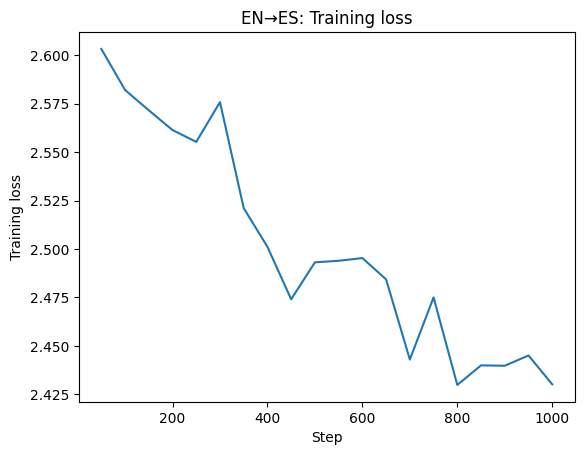

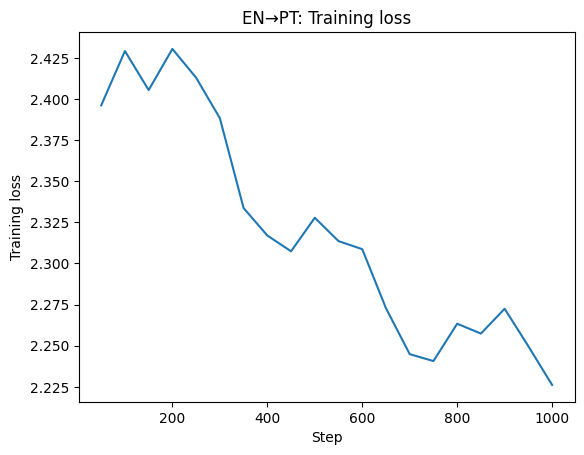

In [18]:
def plot_loss(trainer, title):
    loss_points = [(e["step"], e["loss"]) for e in getattr(trainer.state, "log_history", []) if "loss" in e]
    if not loss_points:
        print(f"{title}: no loss logs found (set logging_steps > 0).")
        return
    steps, losses = zip(*loss_points)
    plt.figure()
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Training loss")
    plt.title(title)
    plt.show()

plot_loss(trainer_es, "EN→ES: Training loss")
plot_loss(trainer_pt, "EN→PT: Training loss")
